# Multi‑file Kurtogram + Order‑Spectrum Demo

This notebook processes all CSVs in `data/bearing_thl_v1`, one per speed and defect condition.

* **Goal**: show that, after envelope extraction and conversion to the order domain, fault signatures align across different speeds.
* **Steps per file**
  1. Compute spectral kurtosis; pick 2 kHz band.
  2. Band‑pass & Hilbert envelope.
  3. Envelope FFT → convert frequency axis to **order** by dividing by shaft speed (inferred from filename).

---

In [1]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band, plot_sk
from brf_lightning.data.bearing.utils import load_vibration_data

plt.rcParams['figure.dpi'] = 110


In [2]:
# ── Datei-Ablage ───────────────────────────────────────────────────
BASE_DIR      = Path("data/bearing_thl_v1")

# ── Kurtogramm / SK-Analyse ───────────────────────────────────────
NPERSEG_STFT  = 8192          
BANDWIDTH_HZ  = 2000          # Suchbandbreite für SK-Maximum
MIN_FREQ_HZ   = 100.0         # min. Bandgrenze
MAX_RATIO_NQ  = 0.95          # max. Bandgrenze als Anteil Nyquist

# ── Hüllkurven-Spektrum ───────────────────────────────────────────
NFFT_ENV      = 65536         # **Zero-Padding für schlanke Peaks**
WINDOW_FN     = np.hanning    # Fenster über komplette Hüllkurve

# ── Regex-Extractor ───────────────────────────────────────────────
SPEED_RE      = re.compile(r"(\d+)\.csv$")      # captures 10 / 20 / 30
DEFECT_RE     = re.compile(r"^(n|fAII|fIII)")   # captures defect label


In [3]:
speed_re  = re.compile(r"(\d+)\.csv$")          # captures 10 / 20 / 30
defect_re = re.compile(r"^(n|fAII|fIII)")       # captures defect code

def get_speed(fp: Path) -> float:
    return float(speed_re.search(fp.name).group(1))

def get_defect(fp: Path) -> str:
    return defect_re.match(fp.stem).group(1)

## Helper: load and preprocess one file

In [4]:
results = {}

for fp in sorted(BASE_DIR.glob("*.csv")):
    # 1) Rohdaten laden -------------------------------------------------
    df, fs = load_vibration_data(fp)            # user-helper
    x      = df["sensor_bearing"].values.astype(np.float32)
    speed  = get_speed(fp)                      # Wellenfrequenz [Hz]
    defect = get_defect(fp)                     # Label
    
    # 2) Spektrale Kurtosis für bestes Resonanzband --------------------
    f, sk = spectral_kurtosis(
        x, fs,
        nperseg = NPERSEG_STFT                  # **längeres Fenster**
    )
    f_lo, f_hi = max_sk_band(
        f, sk,
        bandwidth = BANDWIDTH_HZ,
        min_freq  = MIN_FREQ_HZ,
        max_ratio = MAX_RATIO_NQ,
    )
    
    # 3) Schmalband-Filter + Hüllkurve ---------------------------------
    nyq = 0.5 * fs
    sos = sig.butter(4, [f_lo/nyq, f_hi/nyq], btype="bandpass", output="sos")
    xf  = sig.sosfiltfilt(sos, x)
    env = np.abs(sig.hilbert(xf))
    
    # 4) Order-Spektrum der Hüllkurve ----------------------------------
    #    Hinweis: Zero-Padding => optisch schmalere Peaks
    spec_c   = np.fft.rfft(env * WINDOW_FN(len(env)), n=NFFT_ENV)  # **n=NFFT_ENV**
    spec_mag = np.abs(spec_c)
    
    freq_Hz  = np.fft.rfftfreq(NFFT_ENV, d=1/fs)                   # **NFFT_ENV**
    orders   = freq_Hz / speed
    
    results[fp.name] = dict(
        defect = defect,
        speed  = speed,
        orders = orders,
        spec   = spec_mag,
    )

print(f"Processed {len(results)} traces")


Processed 9 traces


## Process all files

## Plot order spectra grouped by defect

In [ ]:
# Dateien nach Defekt gruppieren
defect_groups = {}
for fname in results:
    tag = fname.split("10")[0]          # crude grouping by prefix
    defect_groups.setdefault(tag, []).append(fname)

def plot_group(tag, fnames, xlim=(0, 10)):
    plt.figure(figsize=(6, 3))
    for fn in sorted(fnames):
        r = results[fn]
        plt.plot(r["orders"],
                 20*np.log10(r["spec"]+1e-6),
                 lw=0.8,
                 label=fn.split(".")[0])
    plt.xlim(*xlim)
    plt.ylim(bottom=-20)
    plt.xlabel("Order")
    plt.ylabel("Envelope amplitude [dB]")
    plt.title(f"Envelope Order Spectrum - {tag}")
    plt.grid(ls=":")
    plt.legend(fontsize=7)
    plt.tight_layout()


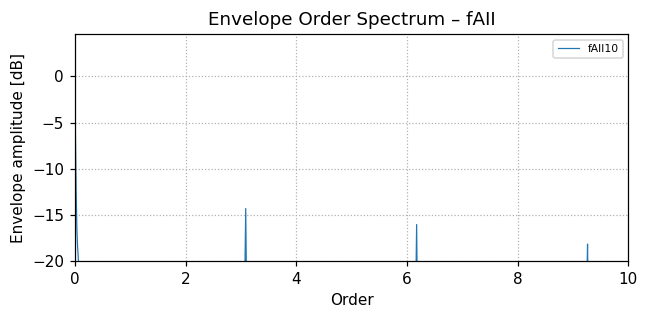

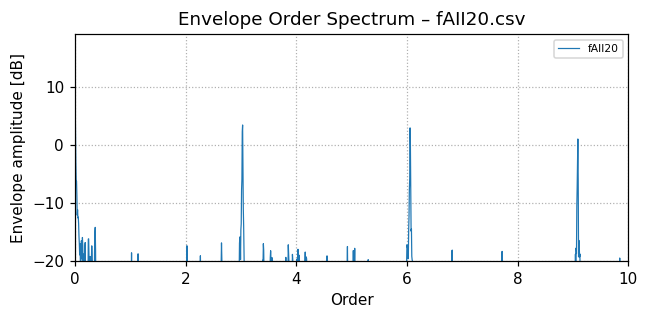

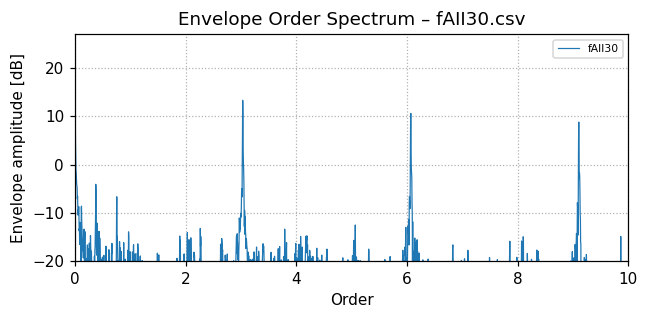

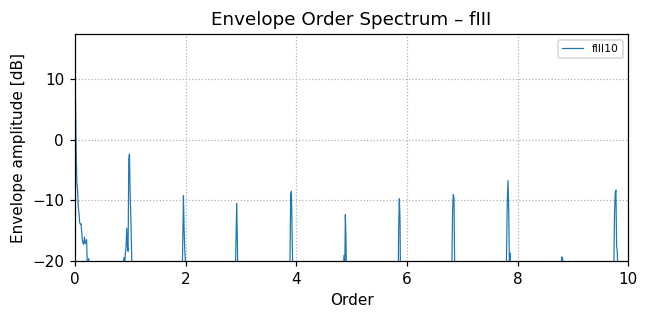

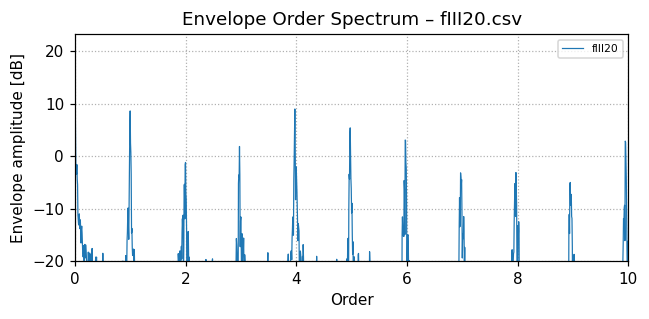

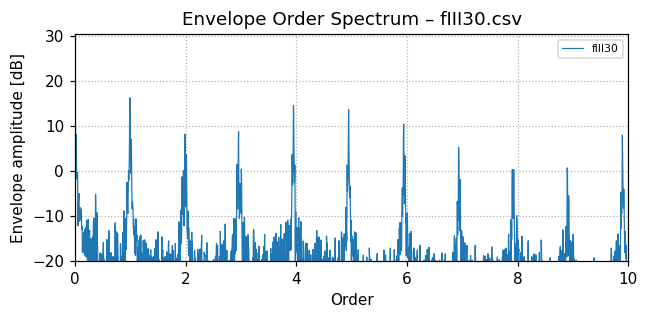

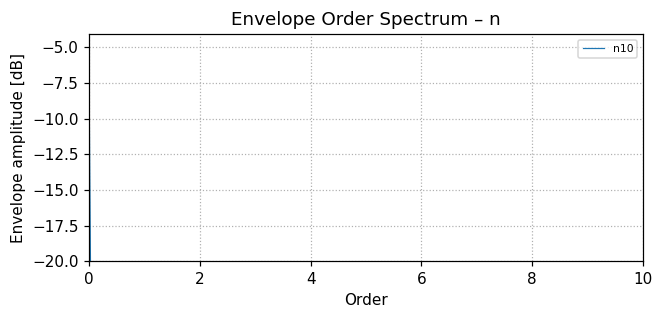

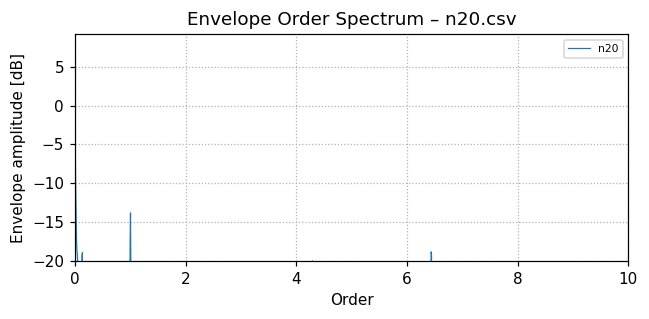

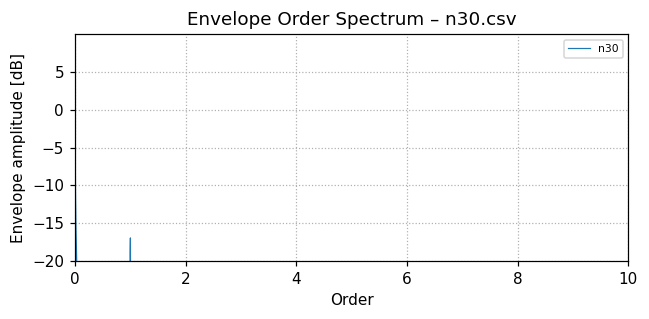

In [7]:
for defect, fnames in defect_groups.items():
    plot_group(defect, fnames)